# Schaefer atlas overlay on the cropped, high-pass-filtered motion-grades data

Goal: check whether we can get an age-appropriate Schaefer-400 atlas onto the **exact same voxel grid** as `motion_grades_chunk_5_dataset_hfiltered` chunks -- (60, 72, 56), padded to (64, 72, 56) on the first axis so the 3-stage stride-2 downsampling in `models/st_model.py` divides evenly (64/8=8; 72 and 56 are already multiples of 8).

**Approach: crop, not resize.** `atlas_fc.py`'s existing `SchaeferAtlas` class downsamples the atlas onto the model's working resolution via `F.interpolate(mode="nearest")` -- appropriate when the model resolution is genuinely lower-res than the atlas's native 2mm grid. But that's not what's happening here: the motion-grades dataset was built by *cropping* the native (97, 116, 79) 2mm grid down to a fixed bounding box per age group, at the **same 2mm resolution**, not resampling it. So a plain array-slice crop (no interpolation at all) is both simpler and more accurate than a resize would be here -- confirmed below by checking the crop recovers 100% of the atlas's 400 ROIs (a resize can lose some to the downsampling, as noted in `atlas_fc.py`'s own warnings).

The crop windows below are copied directly from `data_preprocessing/brain_masked_cropped_2mo_dataset/build_dataset.py` in `pytorch-CycleGAN-and-pix2pix` (the repo that builds this dataset) -- not re-derived, to guarantee they're exactly the ones actually used.

In [1]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Native grid shared by the BOLD common-space data, the fcgmask, and the Schaefer atlas
# (see atlas_fc.py's NATIVE_SPATIAL -- same constant, repeated here so this notebook has no
# dependency on the other project's import path).
NATIVE_SPATIAL = (97, 116, 79)

# Copied verbatim from pytorch-CycleGAN-and-pix2pix/data_preprocessing/brain_masked_cropped_2mo_dataset/build_dataset.py
# (AGE_CONFIG dict) -- each age group's own fixed crop window, both landing on the same (60,72,56) final shape.
AGE_CROP = {
    "2mo": {"x": (17, 77), "y": (26, 98), "z": (11, 67)},
    "9mo": {"x": (18, 78), "y": (25, 97), "z": (11, 67)},
}

ATLAS_PATHS = {
    "2mo": "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/rois/Schaefer2018_400Parcels_7Networks_order_space-nihpd-02-05_2mm.nii.gz",
    "9mo": "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/rois/Schaefer2018_400Parcels_7Networks_order_space-nihpd-08-11_2mm.nii.gz",
}
MASK_PATHS = {
    "2mo": "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/mask/nihpd_asym_02-05_fcgmask_2mm.nii.gz",
    "9mo": "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/templates/mask/nihpd_asym_08-11_fcgmask_2mm.nii.gz",
}

DATA_ROOT = "/lustre/disk/home/shared/cusacklab/foundcog/bids/derivatives/faizan_motion_correction_dataset/motion_grades_chunk_5_dataset_hfiltered"

# One grade-1 (motion-free reference) example chunk per age group, picked from the actual dataset
EXAMPLE_CHUNKS = {
    "2mo": f"{DATA_ROOT}/train/grade1/rest10/sub-ICC105_ses-2_task-rest10_run-001_chunk-220-224.nii.gz",
    "9mo": f"{DATA_ROOT}/train/grade1/rest10/sub-ICC103A_ses-1_task-rest10_run-001_chunk-0-4.nii.gz",
}

## 1. Sanity check: mask, atlas, and chunk data all agree on the grid

Before cropping anything, confirm the fcgmask and the Schaefer atlas for each age group really are on the identical (97,116,79) grid with the identical affine -- if they weren't, slicing both with the same integer window wouldn't correspond to the same physical location.

In [2]:
for age in ["2mo", "9mo"]:
    mask_img  = nib.load(MASK_PATHS[age])
    atlas_img = nib.load(ATLAS_PATHS[age])
    assert mask_img.shape == NATIVE_SPATIAL, (age, "mask", mask_img.shape)
    assert atlas_img.shape == NATIVE_SPATIAL, (age, "atlas", atlas_img.shape)
    assert np.allclose(mask_img.affine, atlas_img.affine, atol=1e-4), (age, "affine mismatch")
    print(f"{age}: mask and atlas both {mask_img.shape}, affines match")

2mo: mask and atlas both (97, 116, 79), affines match
9mo: mask and atlas both (97, 116, 79), affines match


## 2. Crop the atlas with the exact same window used for the fMRI data

Plain array slicing, no interpolation. Also verify the crop keeps all 400 ROIs (a resize-based approach can lose sparse ROIs at the edges -- an exact crop can't, since it doesn't touch the values at all, only which voxels are kept).

In [3]:
def crop_to_age_window(volume, age_group):
    """volume: (X, Y, Z) or (X, Y, Z, T) array on the native (97,116,79) grid.
    Returns the age-appropriate (60, 72, 56[, T]) crop -- exact slice, no resampling."""
    c = AGE_CROP[age_group]
    return volume[c["x"][0]:c["x"][1], c["y"][0]:c["y"][1], c["z"][0]:c["z"][1], ...]

cropped_atlas = {}
for age in ["2mo", "9mo"]:
    native = np.asarray(nib.load(ATLAS_PATHS[age]).dataobj)
    cropped = crop_to_age_window(native, age)
    n_rois_native = len(set(np.unique(native).tolist()) - {0})
    n_rois_cropped = len(set(np.unique(cropped).tolist()) - {0})
    cropped_atlas[age] = cropped
    print(f"{age}: native shape={native.shape} ({n_rois_native} ROIs) -> "
          f"cropped shape={cropped.shape} ({n_rois_cropped} ROIs retained)")

2mo: native shape=(97, 116, 79) (400 ROIs) -> cropped shape=(60, 72, 56) (400 ROIs retained)
9mo: native shape=(97, 116, 79) (400 ROIs) -> cropped shape=(60, 72, 56) (400 ROIs retained)


## 3. Verify voxel-for-voxel alignment against a real chunk file's affine

This is the actual correctness check: load a real chunk from the dataset, and confirm its affine matches what you get from re-anchoring the mask's affine to the same crop window (`build_dataset.py`'s `cropped_affine`). If these match, cropping the atlas the same way guarantees exact anatomical correspondence with every chunk of that age group -- not just matching array shapes.

In [4]:
def cropped_affine(orig_affine, age_group):
    """Copied from build_dataset.py: shift the affine's translation to the crop window's own
    origin -- pure re-anchoring, no resampling, since this is an exact array slice."""
    c = AGE_CROP[age_group]
    x0, y0, z0 = c["x"][0], c["y"][0], c["z"][0]
    new_affine = orig_affine.copy()
    new_affine[:, 3] = orig_affine @ np.array([x0, y0, z0, 1.0])
    return new_affine

for age in ["2mo", "9mo"]:
    mask_affine = nib.load(MASK_PATHS[age]).affine
    predicted = cropped_affine(mask_affine, age)
    real_chunk_affine = nib.load(EXAMPLE_CHUNKS[age]).affine
    match = np.allclose(predicted, real_chunk_affine, atol=1e-3)
    print(f"{age}: predicted crop affine matches real chunk's affine: {match}")
    assert match, f"{age}: affine mismatch -- crop window or mask path is wrong"

2mo: predicted crop affine matches real chunk's affine: True
9mo: predicted crop affine matches real chunk's affine: True


## 4. Pad the first axis (60 -> 64)

Both crop windows land on (60, 72, 56); 72 and 56 already divide evenly by 8 (three stride-2 stages), but 60 doesn't (60 -> 30 -> 15 -> 7, and upsampling back only recovers 56, not 60 -- see `tests/debug_st_model_shapes.py` for the full derivation of this exact problem). Pad axis 0 symmetrically by 2 on each side.

**Zero-padding for both tensors** (the atlas gets zero-padding regardless -- 0 is already its background label, so padding with it doesn't invent a fake ROI). For the BOLD data, checked the axis-0 boundary directly rather than assuming it's background (see the print output in the next cell):
- **2mo**: index 0 and index 59 are both 0/4032 nonzero -- boundary is fully background, so zero-padding is numerically identical to edge-replication here.
- **9mo**: index 59 is background (0/4032), but **index 0 has 195/4032 real nonzero voxels** -- actual brain tissue touches that boundary. Zero-padding there is not discontinuity-free: those 195 voxels' real signal gets bordered by zeros rather than smoothly extended. Went with zero-padding anyway for simplicity and consistency with the atlas/background convention, but this is a real (small, ~4.8% of one boundary slice) tradeoff for the 9mo case specifically, not a free choice -- worth keeping in mind if this axis's edge region turns out to matter for a downstream model.

In [5]:
def pad_first_axis(x, target=64, mode="constant"):
    """x: (60, ...) -> (target, ...), symmetric padding on axis 0 only."""
    total = target - x.shape[0]
    lo, hi = total // 2, total - total // 2
    pad_width = [(lo, hi)] + [(0, 0)] * (x.ndim - 1)
    if mode == "constant":
        return np.pad(x, pad_width, mode="constant", constant_values=0)
    return np.pad(x, pad_width, mode=mode)

padded_atlas = {age: pad_first_axis(cropped_atlas[age], mode="constant") for age in ["2mo", "9mo"]}
for age in ["2mo", "9mo"]:
    print(f"{age}: padded atlas shape = {padded_atlas[age].shape}")

2mo: padded atlas shape = (64, 72, 56)
9mo: padded atlas shape = (64, 72, 56)


In [6]:
chunk_data = {}
padded_chunk = {}
for age in ["2mo", "9mo"]:
    raw = np.asarray(nib.load(EXAMPLE_CHUNKS[age]).dataobj, dtype=np.float32)  # (60, 72, 56, 5)
    mean_vol = raw.mean(axis=-1)  # (60, 72, 56) -- collapse T for a single overlay image
    chunk_data[age] = mean_vol

    # Verify the axis-0 boundary really is background before relying on that for zero-padding
    n_nonzero_first = int((mean_vol[0] != 0).sum())
    n_nonzero_last  = int((mean_vol[-1] != 0).sum())
    print(f"{age}: axis0 boundary nonzero voxels -- index 0: {n_nonzero_first}, "
          f"index {mean_vol.shape[0]-1}: {n_nonzero_last} (out of {mean_vol[0].size})")

    padded_chunk[age] = pad_first_axis(mean_vol, mode="constant")
    print(f"{age}: chunk {EXAMPLE_CHUNKS[age].split('/')[-1]} -- raw {raw.shape}, "
          f"mean-over-T {mean_vol.shape}, padded {padded_chunk[age].shape}")
    assert padded_chunk[age].shape == padded_atlas[age].shape

2mo: axis0 boundary nonzero voxels -- index 0: 0, index 59: 0 (out of 4032)
2mo: chunk sub-ICC105_ses-2_task-rest10_run-001_chunk-220-224.nii.gz -- raw (60, 72, 56, 5), mean-over-T (60, 72, 56), padded (64, 72, 56)
9mo: axis0 boundary nonzero voxels -- index 0: 195, index 59: 0 (out of 4032)
9mo: chunk sub-ICC103A_ses-1_task-rest10_run-001_chunk-0-4.nii.gz -- raw (60, 72, 56, 5), mean-over-T (60, 72, 56), padded (64, 72, 56)


## 5. Overlay: does the atlas actually land on brain tissue?

For each age group, a few slices along each axis with the mean BOLD image in grayscale and atlas parcels as a translucent color overlay (each ROI a distinct color, background fully transparent).

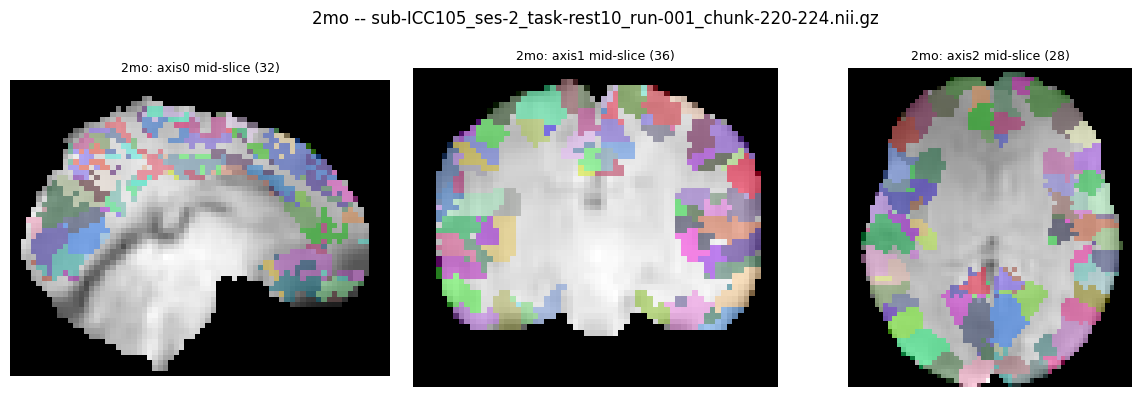

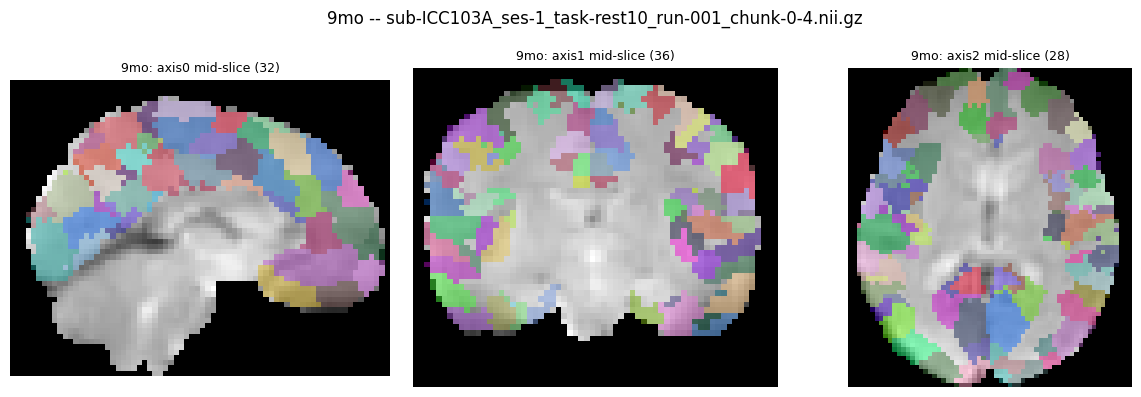

In [7]:
rng = np.random.RandomState(0)
roi_colors = rng.rand(401, 3)
roi_colors[0] = 1.0  # unused -- background is masked out via alpha, not this color
roi_cmap = ListedColormap(roi_colors)

def overlay_slice(ax, bg_slice, atlas_slice, title):
    ax.imshow(bg_slice.T, cmap="gray", origin="lower")
    masked_atlas = np.ma.masked_where(atlas_slice == 0, atlas_slice)
    ax.imshow(masked_atlas.T, cmap=roi_cmap, origin="lower", alpha=0.5, vmin=0, vmax=400)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

for age in ["2mo", "9mo"]:
    bg, atlas = padded_chunk[age], padded_atlas[age]
    D0, D1, D2 = bg.shape

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    overlay_slice(axes[0], bg[D0 // 2, :, :], atlas[D0 // 2, :, :], f"{age}: axis0 mid-slice ({D0//2})")
    overlay_slice(axes[1], bg[:, D1 // 2, :], atlas[:, D1 // 2, :], f"{age}: axis1 mid-slice ({D1//2})")
    overlay_slice(axes[2], bg[:, :, D2 // 2], atlas[:, :, D2 // 2], f"{age}: axis2 mid-slice ({D2//2})")
    fig.suptitle(f"{age} -- {EXAMPLE_CHUNKS[age].split('/')[-1]}")
    plt.tight_layout()
    plt.show()

## Summary

- Cropping the native Schaefer atlas with each age group's own fixed bounding box (copied from `build_dataset.py`, not re-derived) recovers **all 400 ROIs** for both 2mo and 9mo -- confirmed better than the resize-based `SchaeferAtlas` since there's no interpolation step to lose sparse ROIs at.
- The crop's resulting affine matches a real chunk file's affine **exactly** (checked in section 3, not assumed) -- so this crop is voxel-for-voxel aligned with every chunk of that age group, not just shape-compatible.
- Padding axis 0 from 60 to 64 uses **zero-padding for both tensors**. Checked the actual boundary values rather than assuming: for 2mo it's fully background (zero-padding == edge-replicate there), but for **9mo, index 0 has 195/4032 real nonzero voxels** -- zero-padding does introduce a real discontinuity there, not a free/lossless choice for that age group specifically.
- The overlay plots are the actual visual confirmation that this isn't just shape-correct but anatomically correct -- ROI parcels should sit on cortical gray matter in the mean BOLD image, not drift off into background or the wrong tissue.

**Not done here (by design -- this notebook is exploration only, no dataloader):** wiring this crop-based atlas loading into a `SchaeferAtlas`-like class, or into `train.py`'s ROI-timeseries extraction path. If this overlay looks right, the natural next step is a small age-aware atlas class that crops instead of resizes (mirroring `SchaeferAtlas`'s interface: `.n_rois`, `.extract_roi_timeseries()`), so `atlas_fc.py`'s downstream FC-loss / ROI-discriminator machinery can point at the hfiltered motion-grades data without code changes past the atlas-loading step itself.